# What is Filtering?
    - Filtering = changing the value of each pixel based on its neighbors.

    - Think: “Look around a pixel, do some calculation, and replace the pixel with the new value.”

# Why we use it?

    - Remove noise (smoothing)

    - Enhance features (edges, shapes)

# How it Works

    - A kernel (small grid like 3×3 or 5×5) slides over the image.

    - For each pixel:

        - Combine values of the pixel + its neighbors

        - Replace the center pixel with the calculated value

            - Example: 3×3 kernel → looks at 9 pixels at a time

# Filtering Methods in OpenCV
    - A. filter2D

        - What it does: Apply any custom kernel to the image.

            - Example: If your kernel is all ones and normalized, it averages neighbors (like blur).

            - Use case: Custom filters, edge detection, smoothing

            - Layman analogy:
                - “Take the average of the surrounding pixels and replace the center pixel.”

    - B. Bilateral Filter (cv2.bilateralFilter)

        - What it does: Smooths the image without blurring edges.

            - Works by checking:

                - Spatial closeness → nearby pixels only

                - Intensity similarity → only pixels with similar color

                - Use case: Remove noise but keep edges sharp


                - Layman analogy:
                    - “Blur the inside of objects but keep the edges clear.”

                - Good for portraits, where you want smooth skin but sharp facial features.

    - C. Box Filter (cv2.boxFilter)

        - What it does: Similar to average blur, just slides a “box” over the image.

            - Can be normalized (average) or not (sum).

            - Use case: Simple smoothing

            - Layman analogy:
                - “Take the average of a box-shaped area around the pixel and replace the pixel with it.”

    - D. SQRBox Filter (cv2.sqrBoxFilter)

        - What it does: Works like box filter but uses squares of pixel values.

        - Useful for calculating variance or standard deviation in the neighborhood.

        - Use case: Advanced image statistics, not commonly used for normal smoothing

        - Layman analogy:
            - “Look at neighbors, square their brightness, sum it, and replace the center pixel with this value.”

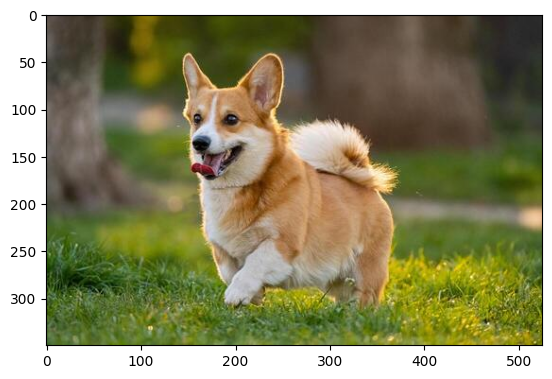

In [43]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread("0_data/dog_img1.jpg")
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

plt.imshow(img)

In [44]:
# Custom Kernel
filter = np.ones((3,3), np.float32)
#print(filter)

# Normalize the kernel values 
filter = filter / 10
print(filter)

[[0.1 0.1 0.1]
 [0.1 0.1 0.1]
 [0.1 0.1 0.1]]


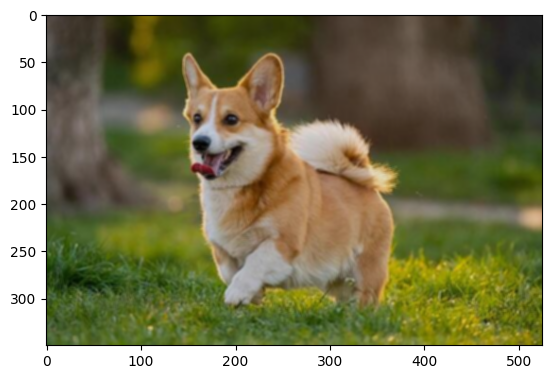

In [45]:
# Apply filter on the image
filtered_img = cv.filter2D(img, -1, filter) # -1 means keep the same data type as the original image, i.e. if image is unit8 then output will also be uint8

plt.imshow(filtered_img)

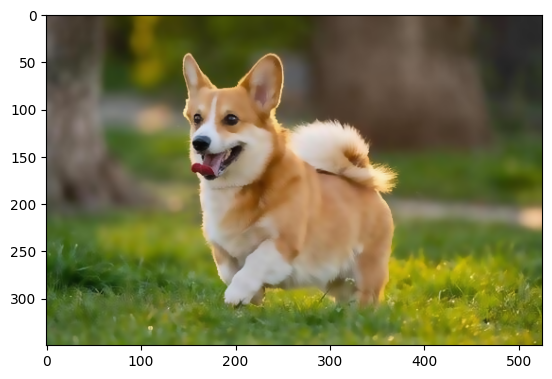

In [46]:
# Bilateral Filter
bilateral_filtered_img = cv.bilateralFilter(img, 9, 75, 75) # 9: how many nearby pixels to consider,
                                        # 75: color sigma (how much colors are considered), big value -> more colors are mixed
                                        # 75: space sigma (how much spatial distance is considered), nearby pixels matter more
plt.imshow(bilateral_filtered_img)

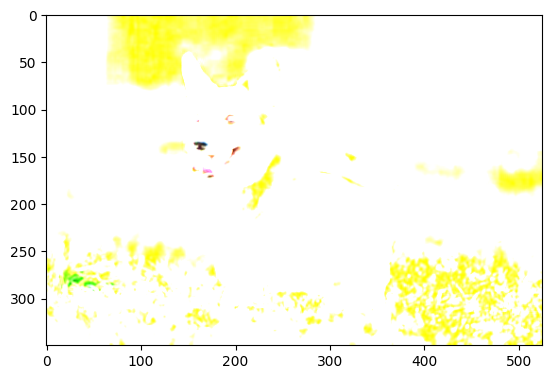

In [47]:
# Box Filter
box_filtered_img = cv.boxFilter(img, 0, (3,3), img, (-1,-1), False, cv.BORDER_DEFAULT)  
# (-1,-1) means: Automatically use the center of kernel
# False → normalize : True → take average (like blur), False → take sum only

plt.imshow(box_filtered_img)

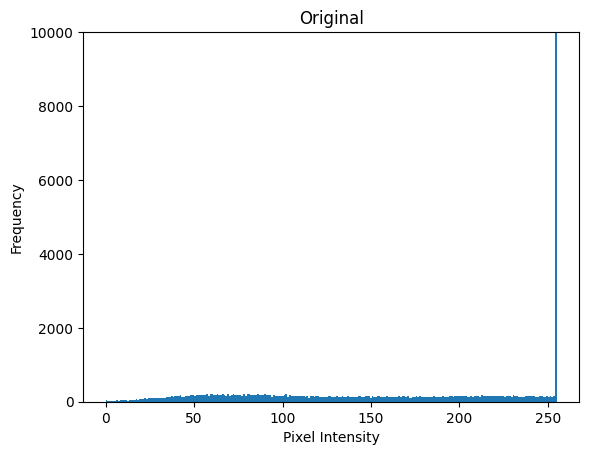

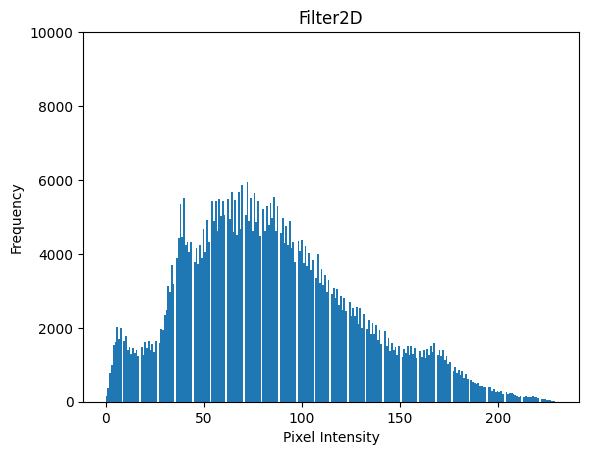

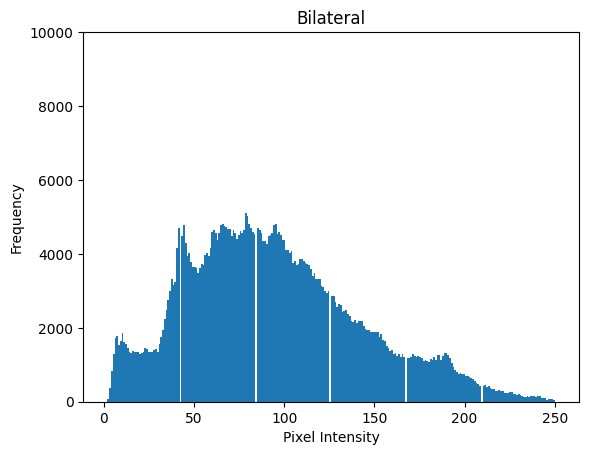

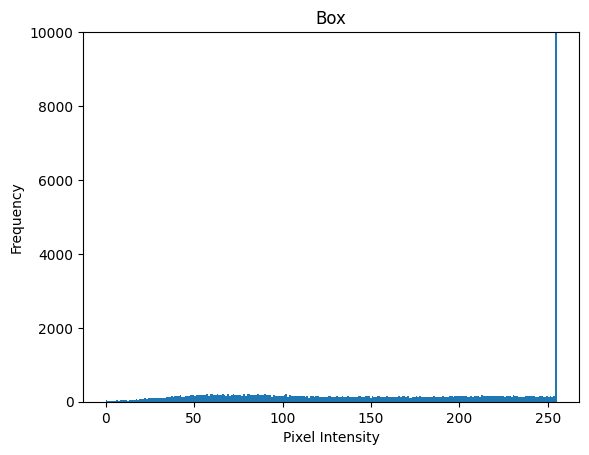

In [51]:
import matplotlib.pyplot as plt

images = {
    "Original": img,
    "Filter2D": filtered_img,
    "Bilateral": bilateral_filtered_img,
    "Box": box_filtered_img,
}

for name, image in images.items():
    plt.figure()
    plt.hist(image.ravel(), bins=256)
    
    plt.title(name)
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Frequency")
    
    plt.ylim(0, 10000)   # 🔥 Limit Y-axis to 10000
    
    plt.show()